In [1]:
from dlfs.base import Module, Loss, Optimizer

from dlfs.modules import SequentialWrapper
from dlfs.layers import DenseLayer
from dlfs.activation import ReLU, Sigmoid

from dlfs.loss import MSE_Loss, BCE_Loss
from dlfs.optimizers import Optimizer_Adam

from dlfs.helpers import DLFSData

import numpy as np
import matplotlib.pyplot as plt

# Variational Autoencoder

- encoder-decoder generative model which learns the underlying data distribution

- as opposed to standard autoencoder which learns latent space representation directly from data, VAE learns to encode data into a distribution characterised by Normal distribution parameters $\mu$ and $\sigma$ (learns to encode data into mean and variance)

- an intermediary variable (latent variable) is sampled from this distribution and passed to decoder to reconstruct the original input data

***

# Forward pass

For input $X \in \mathbb{R}^{n \times m}$ the forward process starts with passing input data through encoder (feed-forward network).

$$Y_{\text{enc}} = \text{ENC}(X)$$

Using the encoder output distribution parameters $\mu$ and $\log(\sigma^2)$ are calculated. This is done using two separates feed-forward networks. Quite often this step is integrated within the encoder forward pass.

$$
\begin{align*}
\mu &= \text{FFWD}_{\mu}(Y_{\text{enc}}) \\
\log(\sigma^2) &= \text{FFWD}_{\log(\sigma^2)}(Y_{\text{enc}})
\end{align*}
$$

Once distribution parameters have been calculated, we use the **reparametrization trick** to calculate the latent variable $Z$ by sampling from the distribution.

$$Z = \mu + \epsilon \odot e^{\frac{1}{2} \log(\sigma^2)}$$

The latent variable $Z$ is then passed to decoder to reconstruct the original input $X$.

$$Y_{\text{dec}} = \text{DEC}(Z)$$

***

# Loss function

Loss function in VAE is a combination of two losses: 

- reconstruction loss responsible for monitoring how well the decoder reconstructs the original input

- KL divergence loss responsible for regularizing the latent space by measuring the difference between the learned distribution $\mathcal{N}(\mu(x), \sigma^2(x))$ and the prior distribution $\mathcal{N}(0, I)$

$$L = L_{\text{rec}} + L_{\text{KL}}$$

Reconstruction loss is often MSE or BCE.

Prior distribution $\mathcal{N}(0, I)$ is chosen because it simplifies the KL divergence term to the following expression: 

$$L_{\text{KL}} = -\frac{1}{2} \sum (1 + \log(\sigma^2) - \mu^2 - e^{\log(\sigma^2)})$$


***

# Loss function gradients

Loss depends on both the decoder output $Y_{\text{DEC}}$ and the distribution parameters $\mu$ and $\log(\sigma^2)$. The gradients are:

$$\frac{\partial L}{\partial \mu} = \frac{\partial L}{\partial L_{\text{KL}}} \cdot \frac{\partial L_{\text{KL}}}{\partial \mu} = 1 \cdot \left( -\frac{1}{2} \right) \cdot (-2 \mu) = \mu \\$$

$$\frac{\partial L}{\partial \log(\sigma^2)} = \frac{\partial L}{\partial L_{\text{KL}}} \cdot \frac{\partial L_{\text{KL}}}{\partial \log(\sigma^2)} = 1 \cdot \left( -\frac{1}{2} \right) \cdot \left(1 - e^{\log(\sigma^2)} \right) = - \frac{1}{2} \left(1 - e^{\log(\sigma^2)} \right) \\$$

$$\frac{\partial L}{\partial Y_{\text{dec}}} = \frac{\partial L}{\partial L_{\text{rec}}} \cdot \frac{\partial L_{\text{rec}}}{\partial Y_{\text{dec}}} = 1 \cdot \delta_{\text{rec}}$$

Gradient $\frac{\partial L_{\text{rec}}}{\partial Y_{\text{dec}}} = \delta_{\text{rec}}$ depends on the choice of reconstruction loss function and is not given in explicit form.

Gradient with respect to decoder output $\frac{\partial L}{\partial Y_{\text{DEC}}}$ is backpropagated to decoder, and gradients with respect to distribution parameters $\frac{\partial L}{\partial \mu}$ and $\frac{\partial L}{\partial \log(\sigma^2)}$ are backpropagated to the reparametrization step.

***

# Reparametrization step gradients

For reparametrization $Z = \mu + \epsilon \odot e^{\frac{1}{2} \log(\sigma^2)}$ we calculate the gradients with respect to $\mu$ and $\log(\sigma^2)$

$$\frac{\partial Z}{\partial \mu} = 1$$

$$\frac{\partial Z}{\partial \log(\sigma^2)} = \frac{1}{2} \epsilon \odot e^{\frac{1}{2}\log(\sigma^2)}$$

Combining the reparametrization step gradients with the upstream gradient from the decoder $\delta_{\text{DEC}} = \frac{\partial L}{\partial Z}$ and the upstream gradients of loss function with respect to distribution parameters $\delta_{\mu} = \frac{\partial L}{\partial L_{\text{KL}}} \frac{\partial L_{\text{KL}}}{\partial \mu}$ and $\delta_{\log(\sigma^2)} = \frac{\partial L}{\partial L_{\text{KL}}} \frac{\partial L_{\text{KL}}}{\partial \log(\sigma^2)}$ we obtain the following expressions:

$$\frac{\partial L}{\partial \mu} = \frac{\partial L}{\partial Z} \cdot \frac{\partial Z}{\partial \mu} + \frac{\partial L}{\partial L_{\text{KL}}} \cdot \frac{\partial L_{\text{KL}}}{\partial \mu} = \delta_{\text{DEC}} + \delta_{\mu}$$

$$\frac{\partial L}{\partial \log(\sigma^2)} = \frac{\partial L}{\partial Z} \cdot \frac{\partial Z}{\partial \log(\sigma^2)} + \frac{\partial L}{\partial L_{\text{KL}}} \cdot \frac{\partial L_{\text{KL}}}{\partial \log(\sigma^2)} = \delta_{\text{DEC}} \odot \left(\frac{1}{2} \epsilon \odot e^{\frac{1}{2}\log(\sigma^2)} \right) + \delta_{\log(\sigma^2)}$$

***

# Encoder gradients

After backpropagating through reparametrization step, we obtain the updated $\delta_{\mu}$ and $\delta_{log(\sigma^2)}$ gradients which are ready to get backpropagated to $\mu$ and $\log(\sigma^2)$ feedforward networks and encoder. 

After backpropagating through $\mu$ and $\log(\sigma^2)$ feedforward networks we get the gradient $\frac{\partial L}{\partial \mu} \frac{\partial \mu}{\partial Y_{\text{enc}}}$ from $\mu$ feedforward and $\frac{\partial L}{\partial \log(\sigma^2)} \frac{\partial \log(\sigma^2)}{\partial Y_{\text{enc}}}$ from $\log(\sigma^2)$ feedforward.

To account for both contributions before backpropagating to encoder we sum the two gradients.

$$\frac{\partial L}{\partial Y_{\text{enc}}} = \frac{\partial L}{\partial \mu} \frac{\partial \mu}{\partial Y_{\text{enc}}} + \frac{\partial L}{\partial \log(\sigma^2)} \frac{\partial \log(\sigma^2)}{\partial Y_{\text{enc}}}$$

In [2]:
class VAE(Module):

    def __init__(self, encoder: Module, decoder: Module, 
                       mu: Module, logvar: Module, 
                       loss_function: Loss = None, optimizer: Optimizer = None):
        """
        Variational Autoencoder generative model.

        Parameters
        ----------
        encoder: Module
            Encoder part of VAE.

        decoder: Module
            Decoder part of VAE.

        mu: Module
            Feed-forward network for predicting mean of distribution.

        logvar: Module
            Feed-forward network for predicting log variance of distribution.
        
        loss_function : Loss, default=None
            Loss function.
        
        optimizer : Optimizer, default=None
            Optimizer algorithm.
        """
        self.encoder = encoder
        self.decoder = decoder
        self.mu = mu
        self.logvar = logvar
        self.loss_function = loss_function
        self.optimizer = optimizer

    def _reparametrize(self, mu: np.ndarray, logvar: np.ndarray) -> None:
        """
        Helper method for the reparametrization trick. Creates latent variable attribute.

        Parameters
        ----------
        mu : np.ndarray
            Mean used to calculate latent variable.

        logvar : np.ndarray
            Log variance used to calculate latent variable.

        Returns
        -------
        None
        """
        self.std = np.exp(0.5 * logvar)
        self.eps = np.random.randn(*self.std.shape)  # random noise
        self.z = mu + self.eps * self.std

    def _reparametrize_backward(self, decoder_dinputs: np.ndarray, grad_kl_mu: np.ndarray, grad_kl_logvar: np.ndarray) -> None:
        """
        Helper method for the backpropagation of reparametrization trick. Creates mu and logvar gradient attributes.

        Parameters
        ----------
        decoder_dinputs : np.ndarray
            Decoder upstream gradient.

        grad_kl_mu : np.ndarray
            Mean upstream gradient from KL loss.

        grad_kl_logvar : np.ndarray
            Log variance upstream gradient from KL loss.

        Returns
        -------
        None
        """
        self.dmu = decoder_dinputs * 1 + grad_kl_mu
        self.dlogvar = decoder_dinputs * (0.5 * self.eps * self.std) + grad_kl_logvar

    def forward(self, x: np.ndarray, training: bool = False) -> None:
        """
        Forward pass for the Variational Autoencoder model. Creates output attribute.

        Parameters
        ----------
        x : np.ndarray
            Input array.

        training : bool, default=False
            A flag indicating whether the model is in training mode (`True`) or inference mode (`False`).
            This controls dropout, which is only applied during training.

        Returns
        -------
        None
        """

        # Pass data through encoder
        self.encoder.forward(x, training=training)

        # Compute distribution parameters from encoder output
        self.mu.forward(self.encoder.output, training=training)
        self.logvar.forward(self.encoder.output, training=training)

        # Using distribution parameters apply the reparametrization
        self._reparametrize(self.mu.output, self.logvar.output)

        # Pass sampled latent variable from reparametrization through decoder 
        self.decoder.forward(self.z, training=training)

        # Network output is the decoder output
        self.output = self.decoder.output

    def backward(self, y_true: np.ndarray, kl_beta: float) -> None:
        """
        Backward pass for the Variational Autoencoder model.

        Parameters
        ----------
        y_true : np.ndarray
            Original inputs used to compute the loss function gradient.

        kl_beta : float
            Coefficient used to scale the KL divergence loss and gradients during the KL warmup phase.

        Returns
        -------
        None
        """

        # Compute loss function grads
        self.loss_function.backward(self.output, y_true, self.mu.output, self.logvar.output, kl_beta)
        recon_grad, mu_grad, logvar_grad = self.loss_function.recon_loss.dinputs, self.loss_function.dmu, self.loss_function.dlogvar

        # Backprop reconstruction loss grad through decoder
        self.decoder.backward(recon_grad)

        # Backprop decoder grad, loss function grads with respect to mu and logvar through reparametrize
        self._reparametrize_backward(self.decoder.dinputs, mu_grad, logvar_grad)

        # Backprop distribution grads through their respective ffwd nets
        self.mu.backward(self.dmu)
        self.logvar.backward(self.dlogvar)

        # Add up the distribution parameter grads for encoder
        total_enc_grad = self.mu.dinputs + self.logvar.dinputs

        # Backprop through encoder
        self.encoder.backward(total_enc_grad)

    def train(self, X: np.ndarray, epochs: int = 1000, batch_size: int = None, print_every: int = None, kl_warmup_steps: int = 0) -> None:
        """
        Train the VAE model for a specified number of epochs, updating parameters using backpropagation.

        Parameters
        ----------
        X : np.ndarray
            Input and ground truth output data for the model.

        epochs : int, default=1000
            The number of epochs to train the model.

        batch_size : int, default=None
            The size of the batch to use for each training step. If `None`, the entire dataset is used
            for each forward/backward pass.

        print_every : int, default=None
            If provided, will print the current loss value every 
            `print_every` epochs.

        kl_warmup_steps : int, default=0
            Number of training epochs to apply the KL divergence downscaling. 
            This is done in order for the model to learn to reconstruct data before regularizing the latent space.

        Returns
        -------
        None
        """

        # Store recon and kl losses separately
        self.rec_loss = []
        self.kl_loss = []

        for i in range(epochs + 1):

            if kl_warmup_steps and kl_warmup_steps > 0:
                # Linear kl_beta during warmup
                self.kl_beta = min(1.0, (i + 1) / float(kl_warmup_steps))
            else:
                self.kl_beta = 1.0

            if batch_size is None:

                # Forward pass
                self.forward(X, training=True)

                # Backward pass
                self.backward(X, self.kl_beta)

                # Update parameters
                self.optimizer.pre_update_parameters()
                self.optimizer.update_parameters(self)
                self.optimizer.post_update_parameters()

                # Caluculate and record losses
                rec_l, kl_l, loss = self.loss_function.calculate(self.output, X, self.mu.output, self.logvar.output, self.kl_beta)
                self.rec_loss.append(rec_l)
                self.kl_loss.append(kl_l)

                if print_every is not None:
                    if not i % print_every:
                        print(f'===== EPOCH : {i} ===== LOSS : {loss:.5f} (Recon: {rec_l:.5f} | KL: {kl_l:.5f})')

            else:

                batch_loss = 0
                rec_loss = 0
                kl_loss = 0
                num_batches = 0

                for j in range(0, len(X), batch_size):

                    # Subset data into a batch
                    batch_X = X[j:j+batch_size, :]

                    # Forward pass
                    self.forward(batch_X)

                    # Calculate current batch loss
                    rec, kl, loss = self.loss_function.calculate(self.output, batch_X, self.mu.output, self.logvar.output)

                    batch_loss += loss
                    rec_loss += rec
                    kl_loss += kl
                    num_batches += 1

                    # Backward pass
                    self.backward(batch_X, self.kl_beta)

                    # Update parameters
                    self.optimizer.pre_update_parameters()
                    self.optimizer.update_parameters(self)
                    self.optimizer.post_update_parameters()

                # Record average batch losses
                avg_batch_loss = batch_loss / num_batches
                avg_rec_loss = rec_loss / num_batches
                avg_kl_loss = kl_loss / num_batches

                self.rec_loss.append(avg_rec_loss)
                self.kl_loss.append(avg_kl_loss)

                if print_every is not None:
                    if not i % print_every:
                        print(f'===== EPOCH : {i} ===== LOSS : {avg_batch_loss:.5f} (Recon: {avg_rec_loss:.5f} | KL: {avg_kl_loss:.5f}) =====')


# Loss function (reconstruction loss + KL divergence loss)

In [3]:
class VAE_Loss(Loss):

    def __init__(self, recon_loss: Loss) -> None:
        """
        Variational Autoencoder loss function consisting of reconstruction loss and KL divergence loss.

        Parameters
        ----------
        recon_loss : Loss
            Loss function used to learn reconstruction of data.
        """
        self.recon_loss = recon_loss()

    def calculate(self, y_pred: np.ndarray, y_true: np.ndarray, mu: np.ndarray, logvar: np.ndarray, kl_beta: float = 1.0) -> tuple[float, float, float]:
        """
        Calculate Variational Autoencoder loss.

        Parameters
        ----------
        y_pred : np.ndarray
            Predicted values.

        y_true : np.ndarray
            True values.

        mu : np.ndarray
            Mean of the latent space distribution.

        logvar : np.ndarray
            Log variance of the latent space distribution.

        kl_beta : float, default=1.0
            Scaling term of the KL divergence loss. Used during KL warmup in training.

        Returns
        -------
        rec_loss, kl_loss, total_loss : tuple[float, float, float]
            Separate recon, KL, and cumulative loss.
        """

        # Calculate recon loss
        recon_loss = self.recon_loss.calculate(y_pred, y_true)

        # Calculate KL divergence loss
        kl_loss = -0.5* np.mean(np.sum(1 + logvar - mu**2 - np.exp(logvar), axis=1))

        # Add up two losses
        total_loss = recon_loss + kl_beta * kl_loss

        return recon_loss, kl_beta * kl_loss, total_loss

    def backward(self, y_pred, y_true, mu, logvar, kl_beta=1.0) -> None:
        """
        Backward pass using Variational Autoencoder loss. Creates gradient attributes with respect to mean and log variance.

        Parameters
        ----------
        y_pred : np.ndarray
            Predicted values.

        y_true : np.ndarray
            True values.

        mu : np.ndarray
            Mean of the latent space distribution.

        logvar : np.ndarray
            Log variance of the latent space distribution.

        kl_beta : float, default=1.0
            Scaling term of the KL divergence loss. Used during KL warmup in training.

        Returns
        -------
        None
        """

        # Calculate recon loss gradient
        self.recon_loss.backward(y_pred, y_true)

        # Calculate KL divergence gradients
        dmu = mu
        dlogvar = -0.5 * (1 - np.exp(logvar))

        # Scale KL divergence gradients by kl_beta
        self.dmu = kl_beta * dmu
        self.dlogvar = kl_beta * dlogvar

# Load data

In [4]:
mnist_path = "../data/mnist"

X_train, y_train, X_test, y_test = DLFSData.load_MNIST(mnist_path)

print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_test: {X_test.shape}, y_test: {y_test.shape}')

X_train: (60000, 28, 28), y_train: (60000,)
X_test: (10000, 28, 28), y_test: (10000,)


In [ ]:
# Selecting images of 3s and 7s
X_train, _ = DLFSData.select_MNIST_labels(X_train, y_train, labels=[3, 7], limit=500)
X_train = DLFSData.normalize_MNIST(X_train, range=(0, 1))

X_train = X_train.reshape(-1, 28*28)
print(f'X_train: {X_train.shape}')

X_train: (1000, 784)


# Defining network components

In [6]:
input_dim = 784
hidden_dim = 128
latent_dim = 64

# Encoder feedforward
enc = SequentialWrapper(
    [DenseLayer(input_dim, hidden_dim),
     ReLU(),
     DenseLayer(hidden_dim, hidden_dim),
     ReLU()]
)

# Mean feedforward
mu = SequentialWrapper(
    [DenseLayer(hidden_dim, latent_dim),
     ReLU()]
)

# Log variance feedforward
logvar = SequentialWrapper(
    [DenseLayer(hidden_dim, latent_dim),
     ReLU()]
)

# Decoder feedforward
dec = SequentialWrapper(
    [DenseLayer(latent_dim, hidden_dim),
     ReLU(),
     DenseLayer(hidden_dim, hidden_dim),
     ReLU(),
     DenseLayer(hidden_dim, input_dim),
     Sigmoid()
     ]
)

# Model training

In [7]:
lr = 1e-3
epochs = 3000
batch_size = None

loss_fn = VAE_Loss(recon_loss=BCE_Loss)
optimizer = Optimizer_Adam(learning_rate=lr)

model = VAE(encoder=enc, 
            decoder=dec, 
            mu=mu, 
            logvar=logvar, 
            loss_function = loss_fn, 
            optimizer=optimizer)

model.train(X_train, epochs=epochs, batch_size=batch_size, print_every=600, kl_warmup_steps=900)

===== EPOCH : 0 ===== LOSS : 796.49593 (Recon: 796.48793 | KL: 0.00800)
===== EPOCH : 600 ===== LOSS : 132.98842 (Recon: 116.59879 | KL: 16.38962)
===== EPOCH : 1200 ===== LOSS : 130.04405 (Recon: 110.13216 | KL: 19.91189)
===== EPOCH : 1800 ===== LOSS : 125.47196 (Recon: 104.72305 | KL: 20.74891)
===== EPOCH : 2400 ===== LOSS : 122.40122 (Recon: 101.40709 | KL: 20.99412)
===== EPOCH : 3000 ===== LOSS : 119.34221 (Recon: 98.03717 | KL: 21.30504)


# Loss graph

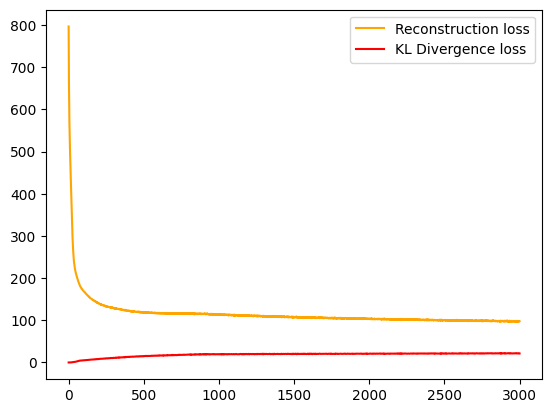

In [8]:
plt.plot(range(len(model.rec_loss)), model.rec_loss, color='orange', label='Reconstruction loss')
plt.plot(range(len(model.kl_loss)), model.kl_loss, color='red', label='KL Divergence loss')
plt.legend()
plt.show()

# Generating new images

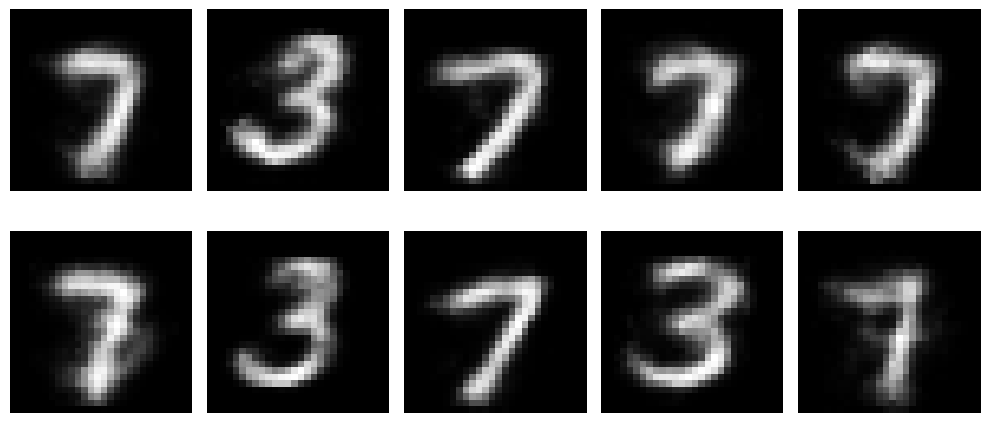

In [15]:
num_img = 10 

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
axes = axes.flatten()

# Sample from random normal
Z = np.random.randn(num_img, latent_dim)

# Pass through decoder to reconstruct
model.decoder.forward(Z)

# Generate and plot n images
for i in range(num_img):
    img = model.decoder.output[i].reshape(28, 28)  # Reshape the output to 28x28 image
    axes[i].imshow(img, cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.show()